# **Installation**

In [54]:
%pip install librosa
from IPython.display import display, Markdown
import librosa
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


# **Importation de l'audio**

[ 6.34369553e-12  3.00205347e-11  1.27517745e-11 ... -4.77221818e-07
  7.23906396e-07 -9.49109733e-07]
Taux d'échantillonage : 22050 

Nombre de sample : (22756,) 

Durée de l'extrait : 1.0320181405895692 s



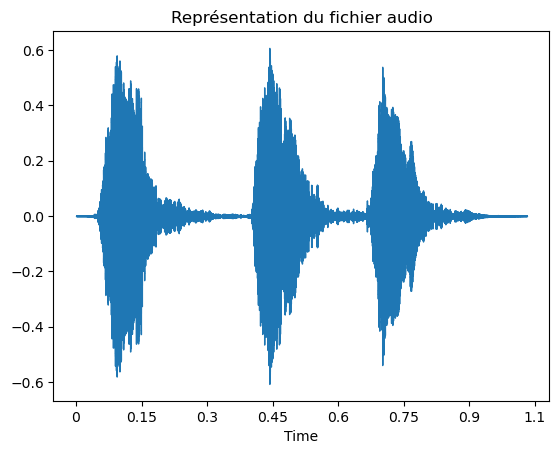

In [55]:
y, sr = librosa.load("dog.mp3")
#audio signal loaded as an array of samples stored in y
#sample rate stored in sr

fig, ax = plt.subplots()
librosa.display.waveshow(y=y, sr=sr, ax=ax)
ax.set(title="Représentation du fichier audio")

print(y)
print("Taux d'échantillonage :",sr,"\n")

print("Nombre de sample :", y.shape,"\n")
print("Durée de l'extrait :", y.shape[0] / sr, "s\n")

# **Spectrogramme de Mel** 
#### sans échelle logarithmique


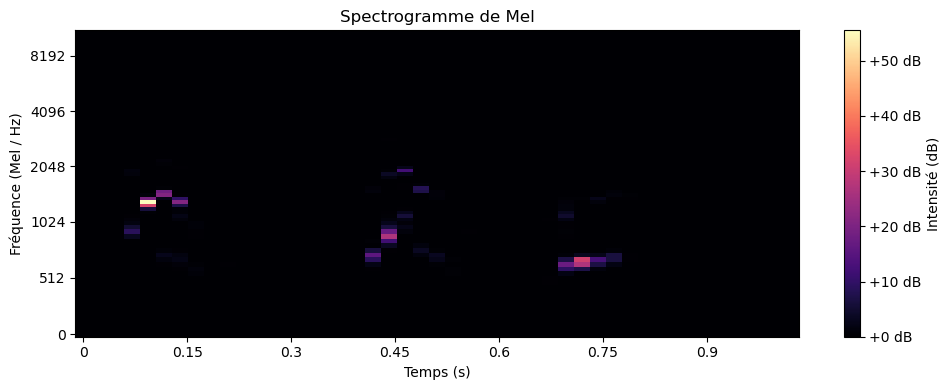

### ***Représentation de la 20ème frame temporelle***

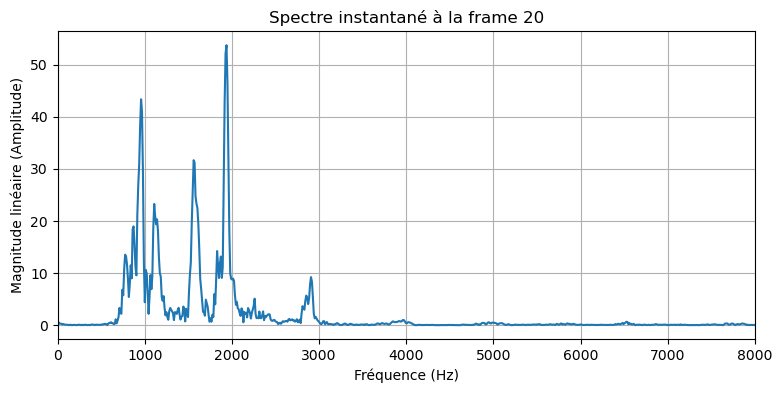

In [61]:
mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=512, hop_length=512, n_mels=80)


plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_spectrogram,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB', label='Intensité (dB)')
plt.title("Spectrogramme de Mel")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Mel / Hz)")
plt.tight_layout()
plt.show()



display(Markdown('### ***Représentation de la 20ème frame temporelle***'))

stft = librosa.stft(y, n_fft=2048, hop_length=512)
magnitude = np.abs(stft)


frame_idx = 20
instant_spectrum = magnitude[:, frame_idx]

freq_bins = librosa.fft_frequencies(sr=sr, n_fft=2048)

plt.figure(figsize=(9, 4))
plt.plot(freq_bins, instant_spectrum)
plt.title(f"Spectre instantané à la frame {frame_idx}")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Magnitude linéaire (Amplitude)")
plt.xlim(0, 8000)
plt.grid(True)
plt.show()


# Spectogramme de Mel 
#### en échelle logarithmique

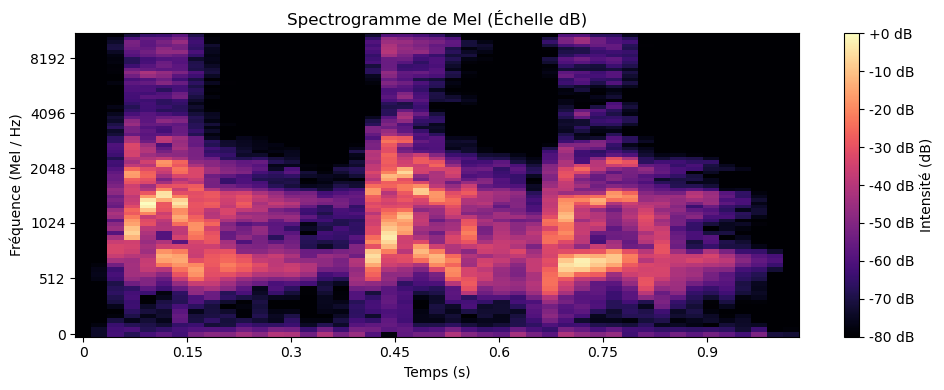

In [62]:
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

# 2. Affichage graphique
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel_spectrogram_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB', label='Intensité (dB)')
plt.title("Spectrogramme de Mel (Échelle dB)")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Mel / Hz)")
plt.tight_layout()
plt.show()